In [57]:
import random
import requests
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
from scipy.stats import entropy, wasserstein_distance, truncnorm
from scipy.spatial.distance import jensenshannon


import geopandas as gpd
from scipy.stats import lognorm
from shapely.geometry import Point
from shapely import wkt
from matplotlib import cm, colors
import contextily as ctx


import Utility as utl
import Utility_individual as uti
import Utility_Housing as uth

# Household Generation

In [ ]:
# Household Margins Readin and Mapping
# --- Configuration ---
api_key = ""
state   = "36"
county  = "061"

dfs   = utl.fetch_census_data(state, county, api_key)
dists = utl.aggregate_household_data(dfs)


In [3]:
print(dfs)

{'DP02_0016E':                         NAME DP02_0016E state county
0  New York County, New York       2.01    36    061, 'DP02_0017E':                         NAME DP02_0017E state county
0  New York County, New York       2.95    36    061, 'S2501_C01_002E':                         NAME S2501_C01_002E state county
0  New York County, New York         367075    36    061, 'S2501_C01_003E':                         NAME S2501_C01_003E state county
0  New York County, New York         238231    36    061, 'S2501_C01_004E':                         NAME S2501_C01_004E state county
0  New York County, New York          91350    36    061, 'S2501_C01_005E':                         NAME S2501_C01_005E state county
0  New York County, New York          78720    36    061, 'S2501_C01_010E':                         NAME S2501_C01_010E state county
0  New York County, New York         215286    36    061, 'S2501_C01_015E':                         NAME S2501_C01_015E state county
0  New York Count

In [4]:
dists

{'avg_household_size': 2.01,
 'avg_family_size': 2.95,
 'household_size_dist': {'1': 367075, '2': 238231, '3': 91350, '4+': 78720},
 'household_type_dist': {'family_married': 215286,
  'family_other_male': 24389,
  'family_other_female': 82447,
  'nonfam_alone': 367075,
  'nonfam_not_alone': 86179},
 'income_all': [7.3, 4.9, 6.2, 4.8, 6.5, 10.2, 8.6, 13.4, 9.4, 28.7],
 'income_families': [4.7, 2.9, 5.3, 4.7, 6.2, 9.2, 7.3, 11.6, 8.9, 39.3],
 'income_married': [1.6, 1.3, 3.2, 2.8, 3.8, 6.5, 5.8, 11.0, 10.8, 53.2],
 'income_nonfamily': [9.2, 6.5, 6.9, 4.9, 6.7, 11.2, 9.6, 14.7, 9.4, 20.8],
 'hh_with_child': {'married': 80952,
  'other_male': 10825,
  'other_female': 41527,
  'nonfamily': 462},
 'relationship_counts': {'householder': 775376,
  'spouse': 214856,
  'partner': 49921,
  'child': 315229,
  'other_rel': 98644,
  'other_nonrel': 101840},
 'gp_households': {'with_gp': 14283,
  'gp_responsible': 3998,
  'gp_no_parent': 1488,
  'other_gp': 2510},
 'children_count_by_family': {'B170

In [5]:
df_hh = utl.generate_households_ipf(dists)
df_hh

,size,type,income_bracket,child_count,householder_cnt,spouse_cnt,child_cnt,other_rel_cnt,other_nonrel_cnt
0,2,family_other_female,8,0,1,0,0,1,0
1,1,nonfam_alone,4,0,1,0,0,0,0
2,1,nonfam_alone,6,0,1,0,0,0,0
3,2,family_married,9,0,1,1,0,0,0
4,1,nonfam_alone,5,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...
775371,1,nonfam_alone,8,0,1,0,0,0,0
775372,1,nonfam_alone,7,0,1,0,0,0,0
775373,1,nonfam_alone,0,0,1,0,0,0,0
775374,1,nonfam_alone,3,0,1,0,0,0,0


In [6]:
eval_df = utl.evaluate_households(df_hh, dists)
print(eval_df)

                                         KL        JS       EMD      RMSE  \
household_size                     0.000012  0.002081  0.003937  0.001462   
household_type                     0.000000  0.000000  0.000000  0.000000   
income_all                         0.004033  0.038197  0.238074  0.012553   
income_family_married              0.000013  0.002128  0.002914  0.000438   
income_family_other_male           0.000275  0.009935  0.031246  0.002118   
income_family_other_female         0.000059  0.004599  0.007040  0.000844   
income_nonfam_alone                0.000004  0.001196  0.002408  0.000287   
income_nonfam_not_alone            0.000109  0.006271  0.012907  0.001331   
has_child_family_married           0.147809  0.217583  0.223233  0.223233   
has_child_family_other_male        0.006260  0.047553  0.055886  0.055886   
has_child_family_other_female      0.000038  0.003719  0.004379  0.004379   
has_child_nonfam_alone             0.005597  0.024637  0.001253  0.001253   

# Individual Generation

In [7]:
dfs_ind = uti.fetch_individual_marginals(state, county, api_key)
indiv_dists = uti.aggregate_individual_marginals(dfs_ind)

In [8]:
age_bin_labels = [
    "Under 5 years","5 to 9 years","10 to 14 years","15 to 19 years",
    "20 to 24 years","25 to 29 years","30 to 34 years","35 to 39 years",
    "40 to 44 years","45 to 49 years","50 to 54 years","55 to 59 years",
    "60 to 64 years","65 to 69 years","70 to 74 years","75 to 79 years",
    "80 to 84 years","85 years and over"
]
age_bin_ranges = {
    "Under 5 years":      (0,4),    "5 to 9 years":      (5,9),
    "10 to 14 years":     (10,14),  "15 to 19 years":    (15,19),
    "20 to 24 years":     (20,24),  "25 to 29 years":    (25,29),
    "30 to 34 years":     (30,34),  "35 to 39 years":    (35,39),
    "40 to 44 years":     (40,44),  "45 to 49 years":    (45,49),
    "50 to 54 years":     (50,54),  "55 to 59 years":    (55,59),
    "60 to 64 years":     (60,64),  "65 to 69 years":    (65,69),
    "70 to 74 years":     (70,74),  "75 to 79 years":    (75,79),
    "80 to 84 years":     (80,84),  "85 years and over": (85,100),
}

In [9]:
df_ages = uti.generate_ages_ipf_constrained(df_hh, indiv_dists['age_dist'], age_bin_labels, age_bin_ranges, seed=42)
df_ages

,household_id,relationship,age
0,0,Head,67
1,0,OtherRelative,73
2,1,Head,20
3,2,Head,55
4,3,Head,59
...,...,...,...
1562348,775373,Head,60
1562349,775374,Head,44
1562350,775375,Head,26
1562351,775375,OtherRelative,83


In [10]:
df_demog = uti.assign_demographics_ipf(df_ages, indiv_dists, age_bin_labels, age_bin_ranges, seed=42)
df_demog

,household_id,relationship,age,gender,employment,education
0,0,Head,67,female,35+_hrs,bachelor
1,0,OtherRelative,73,female,none,graduate
2,1,Head,20,female,35+_hrs,Under25
3,2,Head,55,female,35+_hrs,graduate
4,3,Head,59,female,none,graduate
...,...,...,...,...,...,...
1562348,775373,Head,60,female,35+_hrs,associate
1562349,775374,Head,44,male,35+_hrs,graduate
1562350,775375,Head,26,female,35+_hrs,bachelor
1562351,775375,OtherRelative,83,male,15-34_hrs,graduate


In [11]:
metrics = uti.compare_age_metrics(df_ages, indiv_dists['age_dist'], age_bin_labels, age_bin_ranges)
print(pd.Series(metrics))

KL       0.033068
JS       0.009090
EMD      3.280730
RMSE     0.011770
MAPE    19.864642
dtype: float64


# Housing

In [84]:
BRACKET_MEDIANS = {
    0:   5_000,    # < $10k
    1:  12_500,    # 10–15k
    2:  20_000,    # 15–25k
    3:  30_000,    # 25–35k
    4:  42_500,    # 35–50k
    5:  62_500,    # 50–75k
    6:  87_500,    # 75–100k
    7: 125_000,    # 100–150k
    8: 175_000,    # 150–200k
    9: 225_000,    # 200k+
}

In [85]:
df_hh["income_est"] = df_hh["income_bracket"].map(BRACKET_MEDIANS)

In [86]:
# Assign housing cost
df_hh["housing_share"] = uth.housing_share(df_hh["income_est"].values)
df_hh["housing_cost"]  = df_hh["housing_share"] * df_hh["income_est"]

print(df_hh[["income_bracket","income_est","housing_share","housing_cost"]])

        income_bracket  income_est  housing_share  housing_cost
0                    8      175000       0.220574  38600.444552
1                    4       42500       0.507650  21575.112099
2                    6       87500       0.345788  30256.472926
3                    9      225000       0.218612  49187.649642
4                    5       62500       0.378787  23674.183291
...                ...         ...            ...           ...
775371               8      175000       0.258028  45154.960346
775372               7      125000       0.289736  36216.986998
775373               0        5000       0.652614   3263.069175
775374               3       30000       0.508097  15242.911285
775375               5       62500       0.426253  26640.783826

[775376 rows x 4 columns]


In [87]:
building_data = pd.read_csv('Manhattan_Output_Building_Dataset.CSV') # gain using building process

residential_df = building_data[building_data['subtype'] == 'residential']

In [88]:
residential_df

,id,names,subtype,class,height,is_underground,geometry,area,capacity,centroid,lon,lat
0,08b2a1072d8b1fff0200ace04241e327,NaN,residential,apartments,60.0,False,"POLYGON ((-73.9823938 40.7110039, -73.9824194 ...",987.575999,59254.559961,POINT (-73.98225670558762 40.71111517023472),-73.982257,40.711115
1,08b2a1072d8a2fff020010c6e09fc556,NaN,residential,apartments,60.0,False,"POLYGON ((-73.9815529 40.7110618, -73.9815798 ...",970.497354,58229.841234,POINT (-73.98141849266985 40.71117307867492),-73.981418,40.711173
2,08b2a1072d8b1fff0200af0035e6a390,NaN,residential,NaN,NaN,False,"POLYGON ((-73.9820623 40.7112223, -73.9820274 ...",41.266710,NaN,POINT (-73.98204219999998 40.711186999999995),-73.982042,40.711187
3,08b2a1072d8b4fff020005b22fa2157e,NaN,residential,apartments,17.5,False,"POLYGON ((-73.9821383 40.711889, -73.9821024 4...",1137.498906,19906.230855,POINT (-73.98222714633123 40.71173178434798),-73.982227,40.711732
4,08b2a1072d8b3fff0200ba1701a20930,NaN,residential,NaN,38.3,False,"POLYGON ((-73.9831663 40.7110549, -73.982991 4...",1320.067568,50558.587849,POINT (-73.982917017464 40.71100471958239),-73.982917,40.711005
...,...,...,...,...,...,...,...,...,...,...,...,...
46276,08b2a1008802bfff020093e5ebc669de,NaN,residential,NaN,45.7,False,"POLYGON ((-73.9732903 40.7968959, -73.9733757 ...",1218.036544,55664.270071,POINT (-73.97353264969135 40.7968552830449),-73.973533,40.796855
46277,08b2a1008802bfff02003cd4464efbb5,NaN,residential,NaN,35.1,False,"POLYGON ((-73.9733462 40.7974034, -73.9731218 ...",1426.476984,50069.342136,POINT (-73.973343764906 40.797268061689785),-73.973344,40.797268
46278,08b2a10088028fff02009cb24d6af471,NaN,residential,NaN,38.5,False,"POLYGON ((-73.9733995 40.7977522, -73.9733918 ...",1207.260905,46479.544841,POINT (-73.9733003395005 40.79758804469572),-73.973300,40.797588
46279,08b2a1008802cfff0200f93a5f416b08,NaN,residential,NaN,45.1,False,"POLYGON ((-73.9730926 40.7981133, -73.972911 4...",1629.533313,73491.952403,POINT (-73.97315925294173 40.798004430091915),-73.973159,40.798004


In [ ]:
gdf_tracts_acs, df_county = uth.get_manhattan_tracts_with_acs(api_key="")
print(gdf_tracts_acs.head())
print(df_county)


  STATEFP COUNTYFP TRACTCE        GEOID               GEOIDFQ    NAME  \
0      36      061  030900  36061030900  1400000US36061030900     309   
1      36      061  004400  36061004400  1400000US36061004400      44   
2      36      061  012101  36061012101  1400000US36061012101  121.01   
3      36      061  010803  36061010803  1400000US36061010803  108.03   
4      36      061  010802  36061010802  1400000US36061010802  108.02   

              NAMELSAD  MTFCC FUNCSTAT   ALAND  AWATER     INTPTLAT  \
0     Census Tract 309  G5020        S  302756       0  +40.8758478   
1      Census Tract 44  G5020        S  410012  465240  +40.7278421   
2  Census Tract 121.01  G5020        S   89046       0  +40.7591106   
3  Census Tract 108.03  G5020        S   54399       0  +40.7600939   
4  Census Tract 108.02  G5020        S   57401       0  +40.7591222   

       INTPTLON                                           geometry  \
0  -073.9103730  POLYGON ((-73.91517 40.8757, -73.91512 40.8758.

In [90]:

residential_df = residential_df.copy()
residential_df["geometry"] = residential_df["geometry"].apply(wkt.loads)

gdf_buildings = gpd.GeoDataFrame(residential_df, geometry="geometry", crs="EPSG:4326")

gdf_buildings_priced = uth.assign_building_prices_eq15(
    gdf_buildings,
    gdf_tracts_acs,
    value_col="B25077_001E",
    price_col="price_annual",
    seed=42,
)

# Now gdf_buildings_priced has:
# - one row per residential building
# - geometry, lon, lat, etc.
# - GEOID (tract)
# - B25077_001E (tract median value)
# - price_annual (sampled building price satisfying Eq. 15 logic)


In [91]:
gdf_buildings_priced

,id,names,subtype,class,height,is_underground,geometry,area,capacity,centroid,lon,lat,GEOID,B25077_001E,price_annual
0,08b2a1072d8b1fff0200ace04241e327,NaN,residential,apartments,60.0,False,"POLYGON ((-73.98239 40.711, -73.98242 40.71121...",987.575999,59254.559961,POINT (-73.98225670558762 40.71111517023472),-73.982257,40.711115,36061000202,700100,1.024590e+06
1,08b2a1072d8a2fff020010c6e09fc556,NaN,residential,apartments,60.0,False,"POLYGON ((-73.98155 40.71106, -73.98158 40.711...",970.497354,58229.841234,POINT (-73.98141849266985 40.71117307867492),-73.981418,40.711173,36061000202,700100,7.001000e+05
2,08b2a1072d8b1fff0200af0035e6a390,NaN,residential,NaN,NaN,False,"POLYGON ((-73.98206 40.71122, -73.98203 40.711...",41.266710,NaN,POINT (-73.98204219999998 40.711186999999995),-73.982042,40.711187,36061000202,700100,1.121692e+06
3,08b2a1072d8b4fff020005b22fa2157e,NaN,residential,apartments,17.5,False,"POLYGON ((-73.98214 40.71189, -73.9821 40.7115...",1137.498906,19906.230855,POINT (-73.98222714633123 40.71173178434798),-73.982227,40.711732,36061000202,700100,1.896139e+06
4,08b2a1072d8b3fff0200ba1701a20930,NaN,residential,NaN,38.3,False,"POLYGON ((-73.98317 40.71105, -73.98299 40.711...",1320.067568,50558.587849,POINT (-73.982917017464 40.71100471958239),-73.982917,40.711005,36061000202,700100,6.609738e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46276,08b2a1008802bfff020093e5ebc669de,NaN,residential,NaN,45.7,False,"POLYGON ((-73.97329 40.7969, -73.97338 40.7967...",1218.036544,55664.270071,POINT (-73.97353264969135 40.7968552830449),-73.973533,40.796855,36061018300,1177700,1.226758e+06
46277,08b2a1008802bfff02003cd4464efbb5,NaN,residential,NaN,35.1,False,"POLYGON ((-73.97335 40.7974, -73.97312 40.7973...",1426.476984,50069.342136,POINT (-73.973343764906 40.797268061689785),-73.973344,40.797268,36061018700,1648100,3.916116e+06
46278,08b2a10088028fff02009cb24d6af471,NaN,residential,NaN,38.5,False,"POLYGON ((-73.9734 40.79775, -73.97339 40.7977...",1207.260905,46479.544841,POINT (-73.9733003395005 40.79758804469572),-73.973300,40.797588,36061018700,1648100,9.662591e+05
46279,08b2a1008802cfff0200f93a5f416b08,NaN,residential,NaN,45.1,False,"POLYGON ((-73.97309 40.79811, -73.97291 40.798...",1629.533313,73491.952403,POINT (-73.97315925294173 40.798004430091915),-73.973159,40.798004,36061018700,1648100,1.150577e+06


In [92]:
gdf_buildings_priced = gdf_buildings_priced.dropna(subset=["price_annual"]).reset_index(drop=True)


In [93]:
gdf_buildings_priced

,id,names,subtype,class,height,is_underground,geometry,area,capacity,centroid,lon,lat,GEOID,B25077_001E,price_annual
0,08b2a1072d8b1fff0200ace04241e327,NaN,residential,apartments,60.0,False,"POLYGON ((-73.98239 40.711, -73.98242 40.71121...",987.575999,59254.559961,POINT (-73.98225670558762 40.71111517023472),-73.982257,40.711115,36061000202,700100,1.024590e+06
1,08b2a1072d8a2fff020010c6e09fc556,NaN,residential,apartments,60.0,False,"POLYGON ((-73.98155 40.71106, -73.98158 40.711...",970.497354,58229.841234,POINT (-73.98141849266985 40.71117307867492),-73.981418,40.711173,36061000202,700100,7.001000e+05
2,08b2a1072d8b1fff0200af0035e6a390,NaN,residential,NaN,NaN,False,"POLYGON ((-73.98206 40.71122, -73.98203 40.711...",41.266710,NaN,POINT (-73.98204219999998 40.711186999999995),-73.982042,40.711187,36061000202,700100,1.121692e+06
3,08b2a1072d8b4fff020005b22fa2157e,NaN,residential,apartments,17.5,False,"POLYGON ((-73.98214 40.71189, -73.9821 40.7115...",1137.498906,19906.230855,POINT (-73.98222714633123 40.71173178434798),-73.982227,40.711732,36061000202,700100,1.896139e+06
4,08b2a1072d8b3fff0200ba1701a20930,NaN,residential,NaN,38.3,False,"POLYGON ((-73.98317 40.71105, -73.98299 40.711...",1320.067568,50558.587849,POINT (-73.982917017464 40.71100471958239),-73.982917,40.711005,36061000202,700100,6.609738e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35657,08b2a1008802bfff020093e5ebc669de,NaN,residential,NaN,45.7,False,"POLYGON ((-73.97329 40.7969, -73.97338 40.7967...",1218.036544,55664.270071,POINT (-73.97353264969135 40.7968552830449),-73.973533,40.796855,36061018300,1177700,1.226758e+06
35658,08b2a1008802bfff02003cd4464efbb5,NaN,residential,NaN,35.1,False,"POLYGON ((-73.97335 40.7974, -73.97312 40.7973...",1426.476984,50069.342136,POINT (-73.973343764906 40.797268061689785),-73.973344,40.797268,36061018700,1648100,3.916116e+06
35659,08b2a10088028fff02009cb24d6af471,NaN,residential,NaN,38.5,False,"POLYGON ((-73.9734 40.79775, -73.97339 40.7977...",1207.260905,46479.544841,POINT (-73.9733003395005 40.79758804469572),-73.973300,40.797588,36061018700,1648100,9.662591e+05
35660,08b2a1008802cfff0200f93a5f416b08,NaN,residential,NaN,45.1,False,"POLYGON ((-73.97309 40.79811, -73.97291 40.798...",1629.533313,73491.952403,POINT (-73.97315925294173 40.798004430091915),-73.973159,40.798004,36061018700,1648100,1.150577e+06


In [94]:
df_hh

,size,type,income_bracket,child_count,householder_cnt,spouse_cnt,child_cnt,other_rel_cnt,other_nonrel_cnt,income_est,housing_share,housing_cost
0,2,family_other_female,8,0,1,0,0,1,0,175000,0.220574,38600.444552
1,1,nonfam_alone,4,0,1,0,0,0,0,42500,0.507650,21575.112099
2,1,nonfam_alone,6,0,1,0,0,0,0,87500,0.345788,30256.472926
3,2,family_married,9,0,1,1,0,0,0,225000,0.218612,49187.649642
4,1,nonfam_alone,5,0,1,0,0,0,0,62500,0.378787,23674.183291
...,...,...,...,...,...,...,...,...,...,...,...,...
775371,1,nonfam_alone,8,0,1,0,0,0,0,175000,0.258028,45154.960346
775372,1,nonfam_alone,7,0,1,0,0,0,0,125000,0.289736,36216.986998
775373,1,nonfam_alone,0,0,1,0,0,0,0,5000,0.652614,3263.069175
775374,1,nonfam_alone,3,0,1,0,0,0,0,30000,0.508097,15242.911285


In [95]:
total_households = len(df_hh)
gdf_buildings_cap = uth.derive_household_capacity_from_proxy(
    gdf_buildings_priced,
    proxy_col="capacity",           # height * area
    total_households=total_households,
    out_col="HH_capacity"
)

In [96]:
gdf_buildings_cap

,id,names,subtype,class,height,is_underground,geometry,area,capacity,centroid,lon,lat,GEOID,B25077_001E,price_annual,HH_capacity
0,08b2a1072d8b1fff0200ace04241e327,NaN,residential,apartments,60.0,False,"POLYGON ((-73.98239 40.711, -73.98242 40.71121...",987.575999,59254.559961,POINT (-73.98225670558762 40.71111517023472),-73.982257,40.711115,36061000202,700100,1.024590e+06,59
1,08b2a1072d8a2fff020010c6e09fc556,NaN,residential,apartments,60.0,False,"POLYGON ((-73.98155 40.71106, -73.98158 40.711...",970.497354,58229.841234,POINT (-73.98141849266985 40.71117307867492),-73.981418,40.711173,36061000202,700100,7.001000e+05,58
2,08b2a1072d8b1fff0200af0035e6a390,NaN,residential,NaN,NaN,False,"POLYGON ((-73.98206 40.71122, -73.98203 40.711...",41.266710,NaN,POINT (-73.98204219999998 40.711186999999995),-73.982042,40.711187,36061000202,700100,1.121692e+06,5
3,08b2a1072d8b4fff020005b22fa2157e,NaN,residential,apartments,17.5,False,"POLYGON ((-73.98214 40.71189, -73.9821 40.7115...",1137.498906,19906.230855,POINT (-73.98222714633123 40.71173178434798),-73.982227,40.711732,36061000202,700100,1.896139e+06,20
4,08b2a1072d8b3fff0200ba1701a20930,NaN,residential,NaN,38.3,False,"POLYGON ((-73.98317 40.71105, -73.98299 40.711...",1320.067568,50558.587849,POINT (-73.982917017464 40.71100471958239),-73.982917,40.711005,36061000202,700100,6.609738e+05,51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35657,08b2a1008802bfff020093e5ebc669de,NaN,residential,NaN,45.7,False,"POLYGON ((-73.97329 40.7969, -73.97338 40.7967...",1218.036544,55664.270071,POINT (-73.97353264969135 40.7968552830449),-73.973533,40.796855,36061018300,1177700,1.226758e+06,56
35658,08b2a1008802bfff02003cd4464efbb5,NaN,residential,NaN,35.1,False,"POLYGON ((-73.97335 40.7974, -73.97312 40.7973...",1426.476984,50069.342136,POINT (-73.973343764906 40.797268061689785),-73.973344,40.797268,36061018700,1648100,3.916116e+06,50
35659,08b2a10088028fff02009cb24d6af471,NaN,residential,NaN,38.5,False,"POLYGON ((-73.9734 40.79775, -73.97339 40.7977...",1207.260905,46479.544841,POINT (-73.9733003395005 40.79758804469572),-73.973300,40.797588,36061018700,1648100,9.662591e+05,47
35660,08b2a1008802cfff0200f93a5f416b08,NaN,residential,NaN,45.1,False,"POLYGON ((-73.97309 40.79811, -73.97291 40.798...",1629.533313,73491.952403,POINT (-73.97315925294173 40.798004430091915),-73.973159,40.798004,36061018700,1648100,1.150577e+06,74


In [97]:
df_assign = uth.assign_household_building_ids_sorted_capacity(
    df_hh,
    gdf_buildings_cap,
    hh_cost_col="housing_cost",
    b_price_col="price_annual",
    building_id_col="id",
    capacity_col="HH_capacity",
    hh_id_col=None,   # or hh_id_col="household_id" if you have one
)

# df_assign has: hh_key, id


In [98]:
print(df_assign)

        hh_key                                id
0        39924  08b2a100d2c95fff0200b9ab6e205a6f
1       349680  08b2a100d2c95fff0200b9ab6e205a6f
2       305314  08b2a100d2c95fff0200b9ab6e205a6f
3        86381  08b2a100d2c95fff0200b9ab6e205a6f
4       769832  08b2a10725359fff020083fcc8271895
...        ...                               ...
775371  600800  08b2a10089672fff0200d55b00868574
775372  577933  08b2a10089672fff0200d55b00868574
775373  513344  08b2a10089672fff0200d55b00868574
775374   71312  08b2a10089672fff0200d55b00868574
775375  106069  08b2a10089672fff0200d55b00868574

[775376 rows x 2 columns]


## Visualization

C:\Users\Acid\AppData\Local\Temp\ipykernel_34884\3570695286.py:64: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = cm.get_cmap(base, n)


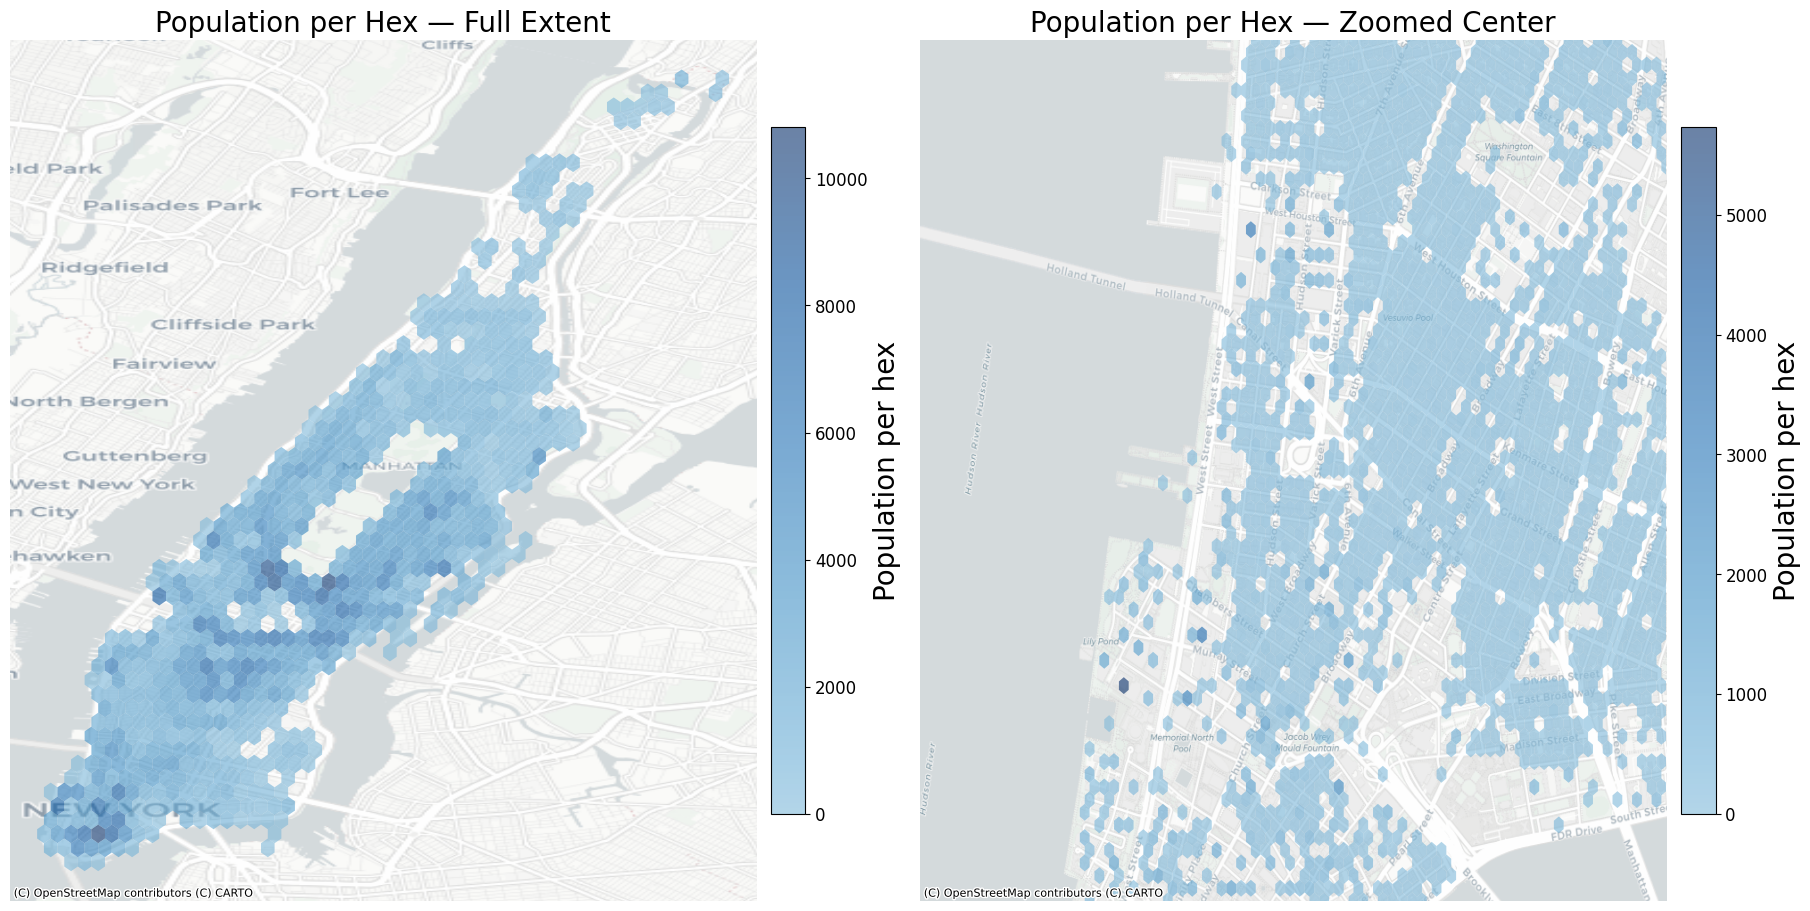

In [99]:
# df_assign: columns ['household_id', 'building_id', 'household_size']
# residential_df: your building table with column 'id'

# 1) Sum individuals per building using your real data
# 1) households per building from df_assign
df_assign_with_size = df_assign.merge(
    df_hh[["size"]],
    left_on="hh_key",
    right_index=True,
    how="left"
)

# 2) Sum people per building
pop_per_building = (
    df_assign_with_size
    .groupby("id")["size"]
    .sum()
)

# 3) Attach to buildings GeoDataFrame
gdf_buildings = gdf_buildings_priced.copy()

gdf_buildings["population"] = (
    gdf_buildings["id"]
    .map(pop_per_building)      # match by building id
    .fillna(0)
    .astype(int)
)

# ... reproject, hexbin, contextily, etc. ...

gdf_points = gpd.GeoDataFrame(
    gdf_buildings,
    geometry=gpd.points_from_xy(gdf_buildings.lon, gdf_buildings.lat),
    crs="EPSG:4326"
)

gdf_points = gdf_points.to_crs(epsg=3857)

xs = gdf_points.geometry.x.values
ys = gdf_points.geometry.y.values
pop = gdf_points['population'].values

# Compute center and zoom window (meters)
xmin, ymin, xmax, ymax = gdf_points.total_bounds
cx, cy = (xmin + xmax) / 2.0, (ymin + ymax) / 2.0
cx = cx - 5000  # slight pan to the west as in your code
cy = cy - 10000
width_m = 4000
half = width_m / 2.0
xlim = (cx - half, cx + half)
ylim = (cy - half, cy + half)

# Mask data for zoom window
mask = (xs >= xlim[0]) & (xs <= xlim[1]) & (ys >= ylim[0]) & (ys <= ylim[1])
xs_zoom = xs[mask]
ys_zoom = ys[mask]
pop_zoom = pop[mask]

# --- Two subplots: left global, right zoomed ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9), constrained_layout=True)

def truncated_cmap(base='Blues', minval=0.45, maxval=1.0, n=256):
    base_cmap = cm.get_cmap(base, n)
    return colors.LinearSegmentedColormap.from_list(
        f'{base}_trunc', base_cmap(np.linspace(minval, maxval, n))
    )
trunc_blues = truncated_cmap('Blues', minval=0.45, maxval=1.0)

# Global hexbin
hb1 = ax1.hexbin(
    xs, ys, C=pop,
    gridsize=50,
    reduce_C_function=np.sum,
    mincnt=1,
    cmap=trunc_blues,       # keep same cmap if you like; scales are independent
    alpha=0.6,
    edgecolors='none'
)
ctx.add_basemap(ax1, source=ctx.providers.CartoDB.Positron, zoom=12)
ax1.set_title('Population per Hex — Full Extent', fontsize=20)
ax1.set_axis_off()

# Zoomed hexbin
hb2 = ax2.hexbin(
    xs_zoom, ys_zoom, C=pop_zoom,
    gridsize=60,
    reduce_C_function=np.sum,
    mincnt=1,
    cmap=trunc_blues,       # independent scale since we won't unify clim
    alpha=0.6,
    edgecolors='none',
)
ax2.set_xlim(xlim)
ax2.set_ylim(ylim)
ctx.add_basemap(ax2, source=ctx.providers.CartoDB.Positron, zoom=15)
ax2.set_title('Population per Hex — Zoomed Center', fontsize=20)
ax2.set_axis_off()

# IMPORTANT: Do NOT unify color scales between subplots
# (i.e., do NOT set shared vmin/vmax or clim)

# Separate colorbars (one per subplot)
cbar1 = fig.colorbar(hb1, ax=ax1, fraction=0.046, pad=0.02)
cbar1.set_label('Population per hex', fontsize=20)
cbar1.ax.tick_params(labelsize=12)  
cbar2 = fig.colorbar(hb2, ax=ax2, fraction=0.046, pad=0.02)
cbar2.set_label('Population per hex', fontsize=20)
cbar2.ax.tick_params(labelsize=12)  

plt.show()




In [100]:
df_hh

,size,type,income_bracket,child_count,householder_cnt,spouse_cnt,child_cnt,other_rel_cnt,other_nonrel_cnt,income_est,housing_share,housing_cost
0,2,family_other_female,8,0,1,0,0,1,0,175000,0.220574,38600.444552
1,1,nonfam_alone,4,0,1,0,0,0,0,42500,0.507650,21575.112099
2,1,nonfam_alone,6,0,1,0,0,0,0,87500,0.345788,30256.472926
3,2,family_married,9,0,1,1,0,0,0,225000,0.218612,49187.649642
4,1,nonfam_alone,5,0,1,0,0,0,0,62500,0.378787,23674.183291
...,...,...,...,...,...,...,...,...,...,...,...,...
775371,1,nonfam_alone,8,0,1,0,0,0,0,175000,0.258028,45154.960346
775372,1,nonfam_alone,7,0,1,0,0,0,0,125000,0.289736,36216.986998
775373,1,nonfam_alone,0,0,1,0,0,0,0,5000,0.652614,3263.069175
775374,1,nonfam_alone,3,0,1,0,0,0,0,30000,0.508097,15242.911285


In [101]:
df_assign

,hh_key,id
0,39924,08b2a100d2c95fff0200b9ab6e205a6f
1,349680,08b2a100d2c95fff0200b9ab6e205a6f
2,305314,08b2a100d2c95fff0200b9ab6e205a6f
3,86381,08b2a100d2c95fff0200b9ab6e205a6f
4,769832,08b2a10725359fff020083fcc8271895
...,...,...
775371,600800,08b2a10089672fff0200d55b00868574
775372,577933,08b2a10089672fff0200d55b00868574
775373,513344,08b2a10089672fff0200d55b00868574
775374,71312,08b2a10089672fff0200d55b00868574
